In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import sys
sys.path.append('../../pybeh')
sys.path.append('../../CourierReinstate1')
import cmlreaders as cml
from cmldask import CMLDask as da
from dask.distributed import wait, as_completed
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
import xarray as xr
import pandas_to_pybeh as pb
import scipy as scp
import re
import math
import pickle
import gc
from scipy import stats
from ptsa.data.filters import ButterworthFilter, MorletWaveletFilter
from ptsa.data.timeseries import *
from statsmodels.stats.multitest import multipletests
from compute_scalp_features import create_baseline_events
from BehavioralFunctions import *
import pyedflib

pd.options.display.max_rows = 100
pd.options.display.max_columns = 50
%matplotlib inline
import importlib
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
import mne
from mne_bids import BIDSPath, read_raw_bids

In [2]:
subjects = ['LTP606', 'LTP607', 'LTP609', 'LTP610', 'LTP612']
experiment = 'valuecourier'
bids_root = "/home1/maint/LTP_BIDS/"

In [3]:
# Convert to DataFrame
def fix_evs(full_evs):
    value_recalls = full_evs[full_evs.trial_type == "VALUE_RECALL"] 
    words = full_evs[full_evs.trial_type == "WORD"]
    rec_words = full_evs[full_evs.trial_type == "REC_WORD"]
    rec_vv_words = full_evs[full_evs.trial_type == "REC_WORD_VV"]

    # WORD --> storepointtype, recalled--> VALUE_RECALL, REC_WORD, REC_WORD_VV
    word_trial_to_storepointtype = words.set_index("trial")["storepointtype"].to_dict()
    word_trial_to_recalled = words.set_index("trial")["recalled"].to_dict()
    for event_type in ["VALUE_RECALL", "REC_WORD", "REC_WORD_VV"]:
        subset = full_evs[full_evs.trial_type == event_type]
        for idx, row in subset.iterrows():
            trial = row["trial"]
            if trial in word_trial_to_storepointtype:
                full_evs.at[idx, "storepointtype"] = word_trial_to_storepointtype[trial]
            if trial in word_trial_to_recalled:
                full_evs.at[idx, "recalled"] = word_trial_to_recalled[trial]

    # VALUE_RECALL --> actualvalue, valuerecall --> WORD, `REC_WORD`, REC_WORD_VV
    valuerecall_trial_to_actualvalue = value_recalls.set_index("trial")["actualvalue"].to_dict()
    valuerecall_trial_to_valuerecall = value_recalls.set_index("trial")["valuerecall"].to_dict()

    # --- Apply to multi-row event types ---
    for event_type in ["WORD", "REC_WORD", "REC_WORD_VV"]:
        subset = full_evs[full_evs.trial_type == event_type]
        for idx, row in subset.iterrows():
            trial = row["trial"]

            # actualvalue
            if trial in valuerecall_trial_to_actualvalue:
                full_evs.at[idx, "actualvalue"] = valuerecall_trial_to_actualvalue[trial]

            # valuerecall
            if trial in valuerecall_trial_to_valuerecall:
                full_evs.at[idx, "valuerecall"] = valuerecall_trial_to_valuerecall[trial]
                
    return full_evs

In [17]:
from mne_bids import BIDSPath, read_raw_bids

bids_path = BIDSPath(
    subject="LTP606",
    session="0",
    task="valuecourier",   # <-- FIXED: lowercase
    datatype="eeg",
    root=bids_root
)

raw = read_raw_bids(bids_path)

raw.set_channel_types({
    'EXG1': 'eog',
    'EXG2': 'eog',
    'EXG3': 'eog',
    'EXG4': 'eog',
    'EXG5': 'misc',
    'EXG6': 'misc',
    'EXG7': 'misc',
    'EXG8': 'misc',
})

events, event_id = mne.events_from_annotations(raw)

epochs = mne.Epochs(
    raw,
    events=events,
    event_id=event_id,
    tmin=-0.2,
    tmax=0.8,
    baseline=(None, 0),
    preload=True,
    event_repeated='merge',   # or 'merge' or 'warn'
)
print("sfreq:", epochs.info["sfreq"])
print("tmin,tmax:", epochs.tmin, epochs.tmax)
print("n_times:", len(epochs.times))
print("duration_s:", epochs.times[-1] - epochs.times[0])

Extracting EDF parameters from /home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_task-valuecourier_eeg.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from /home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_task-valuecourier_events.tsv.
Reading channel info from /home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_task-valuecourier_channels.tsv.
Reading electrode coords from /home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_space-CapTrak_electrodes.tsv.
Used Annotations descriptions: ['FINAL_COMPENSATION', 'POINTER_ON', 'PRACTICE_DELIVERY_END', 'PRACTICE_DELIVERY_START', 'PRACTICE_VALUE_RECALL', 'PRACTICE_WORD', 'REC_START', 'REC_STOP', 'REC_WORD', 'REC_WORD_VV', 'SESS_END', 'SESS_START', 'TL_END', 'TL_START', 'TRIAL_END', 'TRIAL_START', 'VALUE_RECALL', 'VIDEO_START', 'VIDEO_STOP', 'WORD', 'store mappings']
Multiple event values for single event times found. Creating new event value to reflect 

In [18]:
# get full events
full_evs = None
for sub in subjects:
    for session in range(6):
        try:
            bids_path = BIDSPath(
                subject=sub,
                session=str(session),
                task=experiment,  
                datatype="beh",
                extension=".tsv",
                root=bids_root
            )
            evs = pd.read_csv(bids_path.fpath, sep="\t")
            full_evs = evs if full_evs is None else pd.concat([full_evs, evs], ignore_index=True)
        except Exception as e:
            print(e)

cols = ["primacybuf", "recencybuf", "serialpos"]

for c in cols:
    full_evs[c] = (
        pd.to_numeric(full_evs[c], errors="coerce")  # make sure it's numeric, NaNs stay NaN
        .astype("Int64")                             # pandas nullable integer dtype
    )

[Errno 2] No such file or directory: '/home1/maint/LTP_BIDS/sub-LTP612/ses-1/beh/sub-LTP612_ses-1_task-valuecourier'
[Errno 2] No such file or directory: '/home1/maint/LTP_BIDS/sub-LTP612/ses-2/beh/sub-LTP612_ses-2_task-valuecourier'
[Errno 2] No such file or directory: '/home1/maint/LTP_BIDS/sub-LTP612/ses-3/beh/sub-LTP612_ses-3_task-valuecourier'
[Errno 2] No such file or directory: '/home1/maint/LTP_BIDS/sub-LTP612/ses-4/beh/sub-LTP612_ses-4_task-valuecourier'
[Errno 2] No such file or directory: '/home1/maint/LTP_BIDS/sub-LTP612/ses-5/beh/sub-LTP612_ses-5_task-valuecourier'


In [19]:
with open("all_items.txt") as f:
    pool_raw = [w.strip() for w in f if w.strip()]
if pool_raw and pool_raw[0].lower() == "word":
    pool_raw = pool_raw[1:]

pool = [w.upper() for w in pool_raw]
pool_map = {w: i+1 for i, w in enumerate(pool)}

full_evs["itemno"] = full_evs["item"].map(pool_map)
del full_evs

### Encoding

In [20]:
### MNE EXPECTS SECONDS
REL_START, REL_STOP = 0.2, 3
BUFFER_MS = 1
WIDTH = 6

FREQS = np.logspace(np.log10(2), np.log10(100), 46)
NOTCH_BAND = (58., 62.)
BATCH_EVENTS = 64
ROI_ORDER = ['LAI','RAI','LAS','RAS','LPS','RPS','LPI','RPI']

def assign_roi(channel):
    roi_dict = {
        'LAS':['C24','C25','D2','D3','D4','D11','D12','D13'],
        'LAI':['C31','C32','D5','D6','D9','D10','D21','D22'],
        'LPS':['D29','A5','A6','A7','A8','A17','A18'],
        'LPI':['D30','D31','A9','A10','A11','A15','A16'],
        'RAS':['B30','B31','B32','C2','C3','C4','C11','C12'],
        'RAI':['B24','B25','B28','B29','C5','C6','C9','C10'],
        'RPS':['A30','A31','A32','B3','B4','B5','B13'],
        'RPI':['A28','A29','B6','B7','B8','B11','B12'],
    }
    for roi, chans in roi_dict.items():
        if channel in chans:
            return roi
    return None

In [21]:
df_idx = cml.get_data_index('ltp').query("experiment == 'ValueCourier'").copy()
if subjects is not None:
    df_idx = df_idx[df_idx['subject'].isin(subjects)]
subjects = sorted(df_idx.subject.unique())

In [22]:
def welch_t_from_agg(n1, sum1, sumsq1, n0, sum0, sumsq0):
    with np.errstate(divide='ignore', invalid='ignore'):
        m1 = sum1 / np.maximum(n1, 1)
        m0 = sum0 / np.maximum(n0, 1)
        v1 = (sumsq1 - (sum1**2)/np.maximum(n1, 1)) / np.maximum(n1 - 1, 1)
        v0 = (sumsq0 - (sum0**2)/np.maximum(n0, 1)) / np.maximum(n0 - 1, 1)
        denom = np.sqrt(v1 / np.maximum(n1, 1) + v0 / np.maximum(n0, 1))
        t = (m1 - m0) / denom
        t[~np.isfinite(t)] = np.nan
    return t

In [23]:
from mne_bids import get_entity_vals

subjects = get_entity_vals(bids_root, "subject")
subject_root = os.path.join(bids_root, f"sub-{subjects[0]}")
sessions = get_entity_vals(subject_root, "session")
# tasks    = get_entity_vals(bids_root, "task")

In [24]:
sessions

['0', '1', '2', '3', '4', '5']

In [25]:
subjects

['LTP606', 'LTP607', 'LTP609', 'LTP610', 'LTP612', 'LTP613', 'LTP614']

In [27]:
### USING MNE EPOCHS

import os, gc
import numpy as np
import pandas as pd
import mne
from collections import defaultdict
from mne_bids import BIDSPath, read_raw_bids, get_entity_vals

# IMPORTANT: use your already-written class
from ptsa.data.timeseries import TimeSeries  # <-- adjust import path if yours differs


def _align_events_tsv_to_epochs(evs_all, epochs, *, sample_col="sample", raw_first_samp=0):
    """
    Align events.tsv rows to epochs by absolute sample index.
    events.tsv 'sample' is assumed to be ABSOLUTE sample in raw file.

    Returns evs_aligned, epochs_aligned
    """
    # epochs.events[:,0] is sample index relative to raw.first_samp
    epoch_samples_abs = epochs.events[:, 0].astype(np.int64) + int(raw_first_samp)

    sample_to_epoch_idxs = defaultdict(list)
    for ei, s in enumerate(epoch_samples_abs):
        sample_to_epoch_idxs[int(s)].append(ei)

    keep_rows, keep_epoch = [], []
    ev_samples = evs_all[sample_col].astype(np.int64).to_numpy()

    for row_i, s in enumerate(ev_samples):
        lst = sample_to_epoch_idxs.get(int(s), [])
        if lst:
            keep_rows.append(row_i)
            keep_epoch.append(lst.pop(0))

    evs_aligned = evs_all.iloc[keep_rows].reset_index(drop=True)
    epochs_aligned = epochs[keep_epoch]
    return evs_aligned, epochs_aligned


def process_subject_stats(subject, exp, batch):
    # --- sessions for this subject ---
    subject_root = os.path.join(bids_root, f"sub-{subject}")
    sessions = sorted(get_entity_vals(subject_root, "session"), key=lambda s: int(s))

    n1, n0 = {}, {}
    sum1, sum0 = {}, {}
    sumsq1, sumsq0 = {}, {}
    freq_vec = FREQS

    for sess in sessions:
        try:
            bids_path = BIDSPath(
                subject=subject,
                session=str(sess),
                task=exp,
                datatype="eeg",
                root=bids_root,
            )

            # --------------------------
            # Load BIDS events.tsv
            # --------------------------
            events_path = os.path.join(bids_path.directory, bids_path.basename + "_events.tsv")
            evs_all = pd.read_csv(events_path, sep="\t")
            evs_all = fix_evs(evs_all)

            # must exist
            if "trial_type" not in evs_all.columns or "sample" not in evs_all.columns:
                raise ValueError(f"events.tsv missing required cols. Have: {list(evs_all.columns)}")

            # mimic old: keep WORD events only (and valid sample)
            evs_all = evs_all.query("trial_type == 'WORD' and sample >= 0").copy()
            if evs_all.empty:
                continue

            if "recalled" not in evs_all.columns:
                raise ValueError("events.tsv missing 'recalled' column (needed for rec_mask)")

            # --------------------------
            # Load raw
            # --------------------------
            raw = read_raw_bids(bids_path)

            raw.set_channel_types({
                "EXG1": "eog", "EXG2": "eog", "EXG3": "eog", "EXG4": "eog",
                "EXG5": "misc", "EXG6": "misc", "EXG7": "misc", "EXG8": "misc",
            })

            # --------------------------
            # Epoch WORD events from annotations
            # --------------------------
            events, event_id = mne.events_from_annotations(raw)
            word_event_id = {k: v for k, v in event_id.items() if (k == "WORD")}
            if not word_event_id:
                continue

            # ---- CRITICAL: MNE expects SECONDS ----
            # If your constants are in ms, convert here:
            tmin = (-BUFFER_MS)
            tmax = ((REL_STOP + BUFFER_MS))

            epochs = mne.Epochs(
                raw,
                events=events,
                event_id=word_event_id,
                tmin=tmin,
                tmax=tmax,
                # baseline=(None, 0),
                preload=True,
                event_repeated="merge",
            )
            # print("sfreq:", epochs.info["sfreq"])
            # print("tmin,tmax:", epochs.tmin, epochs.tmax)
            # print("n_times:", len(epochs.times))
            # print("duration_s:", epochs.times[-1] - epochs.times[0])

            # We only need EEG channels (exclude eog/misc)
            picks_eeg = mne.pick_types(epochs.info, eeg=True, eog=False, misc=False)
            epochs = epochs.pick(picks_eeg)

            # --------------------------
            # Align evs_all to epochs by sample
            # --------------------------
            evs_all, epochs = _align_events_tsv_to_epochs(
                evs_all, epochs, sample_col="sample", raw_first_samp=raw.first_samp
            )
            
           

            if len(evs_all) == 0 or len(epochs.events) == 0:
                continue

            # sanity check (absolute sample match)
            assert np.all(
                evs_all["sample"].astype(np.int64).to_numpy()
                == (epochs.events[:, 0].astype(np.int64) + int(raw.first_samp))
            ), "events.tsv and epochs misaligned"

            # time slice also in seconds
            rel_start_s = REL_START
            rel_stop_s  = REL_STOP

            # --------------------------
            # Batch loop
            # --------------------------
            for start in range(0, len(evs_all), batch):
                event_df = evs_all.iloc[start:start + batch].reset_index(drop=True)
                rec_mask = event_df["recalled"].to_numpy().astype(bool)

                ep = epochs[start:start + len(event_df)]

                # Build PTSA TimeSeries exactly like old to_ptsa()
                eeg = TimeSeries.from_mne_epochs(ep, event_df)

                # reduce RAM like you wanted
                # eeg = eeg.astype(np.float32)

                # PTSA pipeline (same as old)
                eeg = ButterworthFilter(freq_range=list(NOTCH_BAND), filt_type="stop", order=4).filter(eeg)
                mw = MorletWaveletFilter(freqs=freq_vec, width=WIDTH, output="power", complete=True)
                pwr = mw.filter(eeg).sel(time=slice(rel_start_s, rel_stop_s)).mean(dim="time")

                p = pwr.transpose("event", "channel", "frequency").values
                chans = pwr["channel"].values

                for ch in chans:
                    if ch not in n1:
                        z = np.zeros(len(freq_vec), dtype=np.float64)
                        n1[ch] = 0; n0[ch] = 0
                        sum1[ch] = z.copy(); sum0[ch] = z.copy()
                        sumsq1[ch] = z.copy(); sumsq0[ch] = z.copy()

                if rec_mask.any():
                    vals = p[rec_mask]
                    s = vals.sum(axis=0)
                    ss = (vals ** 2).sum(axis=0)
                    cnt = int(rec_mask.sum())
                    for ci, ch in enumerate(chans):
                        sum1[ch]   += s[ci]
                        sumsq1[ch] += ss[ci]
                        n1[ch]     += cnt

                nrec_mask = ~rec_mask
                if nrec_mask.any():
                    vals = p[nrec_mask]
                    s = vals.sum(axis=0)
                    ss = (vals ** 2).sum(axis=0)
                    cnt = int(nrec_mask.sum())
                    for ci, ch in enumerate(chans):
                        sum0[ch]   += s[ci]
                        sumsq0[ch] += ss[ci]
                        n0[ch]     += cnt

                del eeg, pwr, p
                gc.collect()

            del epochs, raw
            gc.collect()

        except Exception as e:
            print(f"[WARN] {subject} session {sess} skipped: {e}")
            continue

    if not n1:
        return pd.DataFrame(columns=["subject", "channel", "frequency", "t"])

    chans_sorted = sorted(n1.keys())
    C, F = len(chans_sorted), len(freq_vec)

    N1  = np.zeros((C, F));  N0  = np.zeros((C, F))
    S1  = np.zeros((C, F));  S0  = np.zeros((C, F))
    SS1 = np.zeros((C, F));  SS0 = np.zeros((C, F))

    for i, ch in enumerate(chans_sorted):
        N1[i, :]  = n1[ch];       N0[i, :]  = n0[ch]
        S1[i, :]  = sum1[ch];     S0[i, :]  = sum0[ch]
        SS1[i, :] = sumsq1[ch];   SS0[i, :] = sumsq0[ch]

    t_cf = welch_t_from_agg(N1, S1, SS1, N0, S0, SS0)

    df = (
        pd.DataFrame(
            t_cf.reshape(-1),
            index=pd.MultiIndex.from_product([chans_sorted, freq_vec], names=["channel", "frequency"]),
            columns=["t"],
        )
        .reset_index()
    )
    df["subject"] = subject
    return df


In [29]:
# d = process_subject_stats("LTP606", "valuecourier", BATCH_EVENTS)

In [30]:
# d

In [31]:
client = da.new_dask_client_slurm(
    job_name="encoding",
    memory_per_job="100GB",
    max_n_jobs=10,
    queue="RAM",
    local_directory="~/scratch",
    log_directory=os.path.expanduser("~/log_directory")
)

Unique port for zrentala is 51618
{'dashboard_address': ':51618'}
To view the dashboard, run: 
`ssh -fN zrentala@rhino2.psych.upenn.edu -L 8000:192.168.86.140:51618` in your local computer's terminal (NOT rhino) 
and then navigate to localhost:8000 in your browser


In [32]:
# subjects = ['LTP606', 'LTP607', 'LTP609', 'LTP610', 'LTP612']
subjects = ['LTP606']
futures = [client.submit(process_subject_stats, s, experiment, BATCH_EVENTS) for s in subjects]

In [33]:
subj_chan_t_list, n_done, n_fail = [], 0, 0
for fut in as_completed(futures):
    try:
        df_sub = fut.result()
        subj_chan_t_list.append(df_sub)
        n_done += 1
        sub = df_sub['subject'].iat[0] if not df_sub.empty else 'EMPTY_SUBJECT'
        print(f"[DONE] {n_done}/{len(subjects)} :: {sub} (rows={len(df_sub)})")
    except Exception as e:
        n_fail += 1
        print(f"[ERR] Future failed ({n_fail} fails): {e}")

[DONE] 1/1 :: LTP606 (rows=5888)


In [34]:
client.shutdown()

2026-01-23 11:36:24,736 - distributed.deploy.adaptive_core - INFO - Adaptive stop


In [35]:
chan_t_all = (pd.concat(subj_chan_t_list, ignore_index=True)
              if subj_chan_t_list else
              pd.DataFrame(columns=['subject','channel','frequency','t']))
chan_t_all['ROI'] = chan_t_all['channel'].map(assign_roi)
chan_t_all = chan_t_all.dropna(subset=['ROI']).copy()

subj_roi_t = (chan_t_all.groupby(['subject','ROI','frequency'], as_index=False)['t'].mean())

In [36]:
def one_samp(s):
    s = s.dropna()
    if s.empty: return pd.Series({'t_mean':np.nan,'p':np.nan})
    t_mean = s.mean()
    _, p = stats.ttest_1samp(s, 0.0, nan_policy='omit')
    return pd.Series({'t_mean':t_mean, 'p':p})

In [ ]:
mean_tbl = (subj_roi_t
            .groupby(['ROI','frequency'], as_index=False)['t']
            .mean()
            .rename(columns={'t': 't_mean'}))

p_tbl_long = (subj_roi_t
              .groupby(['ROI','frequency'])['t']
              .apply(lambda s: stats.ttest_1samp(s.dropna(), 0.0)[1]
                     if s.notna().any() else np.nan)
              .reset_index(name='p'))

agg = mean_tbl.merge(p_tbl_long, on=['ROI','frequency'], how='outer')

heat = agg.pivot(index='frequency', columns='ROI', values='t_mean')
cols_present = [c for c in ROI_ORDER if c in heat.columns]
if cols_present:
    heat = heat[cols_present]

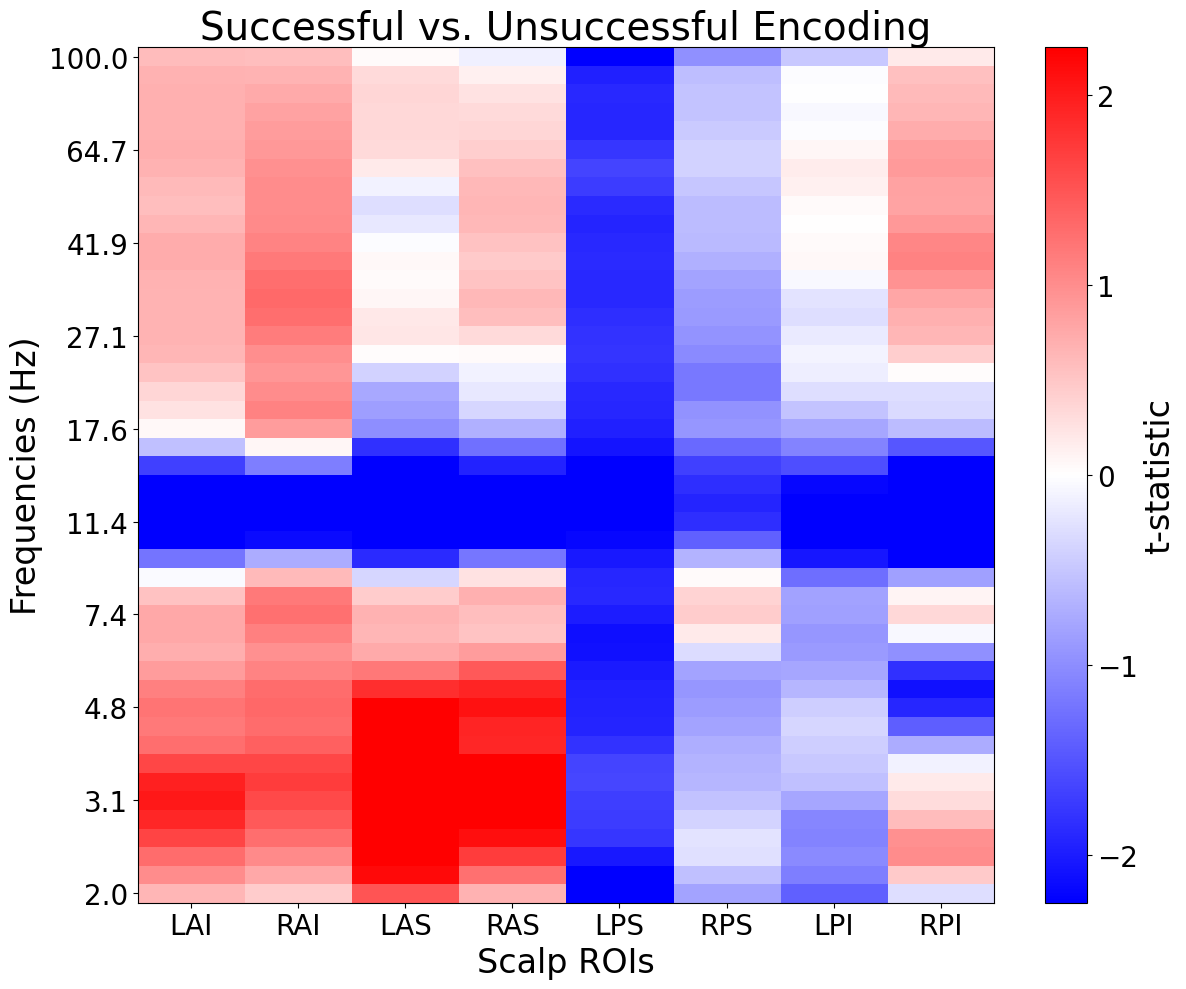

In [ ]:
fig = plt.figure(figsize=(12, 10))
ax = plt.gca()
norm = mcolors.TwoSlopeNorm(vmin=-2.25, vcenter=0.0, vmax=2.25)
im = ax.imshow(heat, cmap='bwr', aspect='auto', norm=norm)

freqs = heat.index.values
tick_idx = np.unique(np.round(np.linspace(0, len(freqs)-1, 10)).astype(int))
ax.set_yticks(tick_idx)
ax.set_yticklabels([f'{freqs[i]:.1f}' for i in tick_idx], fontsize=20)

ax.set_xticks(range(heat.shape[1]))
ax.set_xticklabels(list(heat.columns), fontsize=20)

ax.set_xlabel('Scalp ROIs', fontsize=24)
ax.set_ylabel('Frequencies (Hz)', fontsize=24)
ax.set_title('Successful vs. Unsuccessful Encoding', fontsize=28)

cbar = plt.colorbar(im, ax=ax, fraction=.1)
cbar.set_label('t-statistic', size=24)
cbar.set_ticks([-2, -1, 0, 1, 2])
cbar.ax.tick_params(labelsize=20)

ax.invert_yaxis()
ax.grid(False)
plt.tight_layout()
plt.show()

In [27]:
### Check cml reader path

import os
import cmlreaders as cml

subject = "LTP606"
sess = 0
exp = "ValueCourier"

reader = cml.CMLReader(subject=subject, experiment=exp, session=sess)
evs_cml = reader.load("task_events")

# Most LTP task_events have eegfile; fall back to any column containing "eeg"
eeg_cols = [c for c in evs_cml.columns if "eeg" in c.lower()]
print("EEG-ish columns:", eeg_cols)

# Preferred
if "eegfile" in evs_cml.columns:
    eeg_path = evs_cml["eegfile"].dropna().iloc[0]
else:
    # fallback: pick first non-null from first eeg-ish column
    if not eeg_cols:
        raise RuntimeError("No EEG-related columns found in task_events.")
    col = eeg_cols[0]
    eeg_path = evs_cml[col].dropna().iloc[0]

print("EEG path from events:", eeg_path)

# If it's relative, make it absolute under reader.rootdir
if isinstance(eeg_path, str) and not eeg_path.startswith("/"):
    eeg_path = os.path.join(reader.rootdir, eeg_path)

print("EEG path (absolute):", eeg_path)


EEG-ish columns: ['eegoffset', 'eegfile']
EEG path from events: /protocols/ltp/subjects/LTP606/experiments/ValueCourier/sessions/0/ephys/current_processed/LTP606_session_0.bdf
EEG path (absolute): /protocols/ltp/subjects/LTP606/experiments/ValueCourier/sessions/0/ephys/current_processed/LTP606_session_0.bdf


In [4]:
sess = 0
subject = "LTP606"
### Compare BIDS vs CML Reader
bids_root = "/home1/maint/LTP_BIDS/"
# 1 subject
# events
# CML
reader = cml.CMLReader(subject=subject, experiment="ValueCourier", session=sess)
evs_cml = reader.load('task_events')
evs_cml = evs_cml[(evs_cml['type']=='WORD') & (evs_cml['eegoffset']>=0)]

# BIDS
bids_path = BIDSPath(
    subject=subject,
    session=str(sess),
    task="valuecourier",
    datatype="eeg",
    root=bids_root,
)

# --------------------------
# Load BIDS events.tsv
# --------------------------
events_path = os.path.join(bids_path.directory, bids_path.basename + "_events.tsv")
evs_bids = pd.read_csv(events_path, sep="\t")
evs_bids = fix_evs(evs_bids)

evs_bids = evs_bids.query("trial_type == 'WORD' and sample >= 0").copy()

In [5]:
# check eeg
# CML
REL_START, REL_STOP = 200, 3000
BUFFER_MS = 1000
WIDTH = 6

FREQS = np.logspace(np.log10(2), np.log10(100), 46)
NOTCH_BAND = (58., 62.)
BATCH_EVENTS = 64
eeg_cml = reader.load_eeg().to_ptsa()

Extracting EDF parameters from /protocols/ltp/subjects/LTP606/experiments/ValueCourier/sessions/0/ephys/current_processed/LTP606_session_0.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 10821631  =      0.000 ...  5284.000 secs...


In [ ]:
# bids
REL_START, REL_STOP = 200 /1000, 3000 /1000
BUFFER_MS = 1000 /1000
WIDTH = 6

FREQS = np.logspace(np.log10(2), np.log10(100), 46)
NOTCH_BAND = (58., 62.)
BATCH_EVENTS = 64

bids_path = BIDSPath(
    subject="LTP606",
    session=str(0),
    task="valuecourier",
    datatype="eeg",
    root=bids_root,
)

raw = read_raw_bids(bids_path)

raw.set_channel_types({
    "EXG1": "eog", "EXG2": "eog", "EXG3": "eog", "EXG4": "eog",
    "EXG5": "misc", "EXG6": "misc", "EXG7": "misc", "EXG8": "misc",
})

# raw.drop_channels(
#     [ch for ch in raw.ch_names if raw.get_channel_types(picks=ch)[0] != "eeg"]
# )

# --------------------------
# Epoch WORD events from annotations
# --------------------------
events, event_id = mne.events_from_annotations(raw)
word_event_id = {k: v for k, v in event_id.items() if (k == "WORD")}

# ---- CRITICAL: MNE expects SECONDS ----
# If your constants are in ms, convert here:
tmin = (-BUFFER_MS)
tmax = ((REL_STOP + BUFFER_MS))

epochs_bids = mne.Epochs(
    raw,
    events=events,
    event_id=word_event_id,
    tmin=tmin,
    tmax=tmax,
    baseline=(None, 0),
    preload=True,
    event_repeated="merge",
)

print("sfreq:", epochs_bids.info["sfreq"])
print("tmin,tmax:", epochs_bids.tmin, epochs_bids.tmax)
print("n_times:", len(epochs_bids.times))
print("duration_s:", epochs_bids.times[-1] - epochs_bids.times[0])

eeg_bids = TimeSeries.from_mne_epochs(epochs_bids, evs_bids)

In [6]:
raw = read_raw_bids(
    bids_path,
    verbose=True,
)

eeg_bids = xr.DataArray(
    raw.get_data()[None, :, :],                           # -> (1, n_channels, n_times)
    dims=("event", "channel", "time"),         # match eeg_cml dim names
    coords={
        "event": [0],                          # singleton event index
        "channel": raw.ch_names,
        "time": raw.times  ,
        "samplerate": raw.info["sfreq"],                    # scalar coord (optional)
    },
    name="eeg",
)

Extracting EDF parameters from /home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_task-valuecourier_eeg.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from /home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_task-valuecourier_events.tsv.
Reading channel info from /home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_task-valuecourier_channels.tsv.
Reading electrode coords from /home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_space-CapTrak_electrodes.tsv.


In [4]:
def load_bdf_as_xarray(path: str, *, event_dim_name="event") -> xr.DataArray:
    f = pyedflib.EdfReader(path)
    try:
        n_channels = f.signals_in_file
        ch_names = list(f.getSignalLabels())
        sfreq = float(f.getSampleFrequency(0))
        n_samples = int(f.getNSamples()[0])

        # read + convert each channel explicitly to volts
        data_V = []
        for ch in range(n_channels):
            # print(ch)
            x = f.readSignal(ch)
            unit = f.getPhysicalDimension(ch).lower()

            if unit in ("uv", "µv"):
                x = x * 1e-6          # µV → V
            elif unit == "mv":
                x = x * 1e-3          # mV → V
            elif unit == "v":
                pass                 # already volts
            else:
                print(f"Unknown or invalid physical unit '{unit}' \n" + f"for channel {ch} ({ch_names[ch]})")

            data_V.append(x)

        # shape: (channel, time)
        data = np.vstack(data_V)

        times = np.arange(n_samples) / sfreq

        # add singleton event dimension
        data = data[None, :, :]  # (event=1, channel, time)

        da = xr.DataArray(
            data,
            dims=(event_dim_name, "channel", "time"),
            coords={
                event_dim_name: [0],
                "channel": ch_names,
                "time": times,
                "samplerate": sfreq,
            },
            name="eeg",
            attrs={
                "units": "V",
                "source": "pyedflib (explicitly converted to volts)",
            },
        )

        return da

    finally:
        f.close()

In [8]:
import numpy as np
import xarray as xr
import pandas as pd
import pyedflib
# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
bids_bdf_path = "/home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_task-valuecourier_eeg.bdf|"
cml_bdf_path  = "/protocols/ltp/subjects/LTP606/experiments/ValueCourier/sessions/0/ephys/current_processed/LTP606_session_0.bdf"
eeg_pyedflib = load_bdf_as_xarray(cml_bdf_path)

Unknown or invalid physical unit 'boolean' 
for channel 136 (Status)


# Time dim is different due to floating point error because MNE uses seconds and CMLreader uses ms. After comparing on index and not time, BIDS and CMLReader show the same data

In [5]:
from mne_bids import get_entity_vals
from ReportRawEEG import *
### ACROSS MULTIPLE SUBJECTS AND SESSIONS
bids_root = "/home1/maint/LTP_BIDS/"
subjects = get_entity_vals(bids_root, "subject")


# subject
def process_raw_signals(sub, exp, sess, bids_root, out_path):
    ### load cml
    reader = cml.CMLReader(subject=sub, experiment=exp, session=sess)
    eeg_cml = reader.load_eeg().to_ptsa()

    ### load bdf
    # BIDS
    bids_path = BIDSPath(
        subject=sub,
        session=str(sess),
        task=exp.lower(),
        datatype="eeg",
        root=bids_root,
    )

    raw = read_raw_bids(
        bids_path,
        verbose=True,
    )

    eeg_bids = xr.DataArray(
        raw.get_data()[None, :, :],                           # -> (1, n_channels, n_times)
        dims=("event", "channel", "time"),         # match eeg_cml dim names
        coords={
            "event": [0],                          # singleton event index
            "channel": raw.ch_names,
            "time": raw.times * 1000,
            "samplerate": raw.info["sfreq"],                    # scalar coord (optional)
        },
        name="eeg",
    )
    
    # return eeg_cml, eeg_bids
    

    ## load pyedf
    # cml_bdf_path  = f"/protocols/ltp/subjects/{sub}/experiments/{exp}/sessions/{sess}/ephys/current_processed/{sub}_session_{sess}.bdf"
    # eeg_pyedflib = load_bdf_as_xarray(cml_bdf_path)

    # compare
    results = compare_eeg_sources(
        eeg_dict={"BIDS": eeg_bids, "CMLReader": eeg_cml},
        subject=sub,
        experiment=exp,
        session=sess,
        options=["strip_metadata", "compare_raw_signals", "compare_time_coords"]
    )
    
    results["df_raw"].to_csv(f"{out_path}df_raw_{sub}_{exp}_{sess}.csv", index=False)
    results["df_raw_summary"].to_csv(f"{out_path}df_raw_summary_{sub}_{exp}_{sess}.csv", index=False)
    results["df_time"].to_csv(f"{out_path}df_time_{sub}_{exp}_{sess}.csv", index=False)
    return results


In [5]:
# eeg_cml, eeg_bids = process_raw_signals("LTP606", "ValueCourier", 0, "/home1/maint/LTP_BIDS/", "")

Extracting EDF parameters from /protocols/ltp/subjects/LTP606/experiments/ValueCourier/sessions/0/ephys/current_processed/LTP606_session_0.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 10821631  =      0.000 ...  5284.000 secs...
Extracting EDF parameters from /home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_task-valuecourier_eeg.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from /home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_task-valuecourier_events.tsv.
Reading channel info from /home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_task-valuecourier_channels.tsv.
Reading electrode coords from /home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_space-CapTrak_electrodes.tsv.


In [ ]:
from mne_bids import get_entity_vals
from ReportRawEEG import *
### ACROSS MULTIPLE SUBJECTS AND SESSIONS
bids_root = "/home1/maint/LTP_BIDS/"
subjects = get_entity_vals(bids_root, "subject")


# subject
def process_epoched_signals(sub, exp, sess, evs_types, tmin, tmax, bids_root, out_path):
    evs_types_set = set(evs_types)
    ### load cml
    reader = cml.CMLReader(subject=sub, experiment=exp, session=sess)
    evs_cml = cmlreader.load('events')
    filtered_evs_cml = evs_cml[evs_cml["type"].isin(evs_types_set)]
    eeg_cml = reader.load_eeg(filtered_evs_cml, rel_start=-BUFFER_MS, rel_stop=REL_STOP + BUFFER_MS).to_ptsa()

    ### load bdf
    
    bids_path = BIDSPath(
        subject=subject,
        session=str(sess),
        task=exp,
        datatype="eeg",
        root=bids_root,
    )

    # --------------------------
    # Load BIDS events.tsv
    # --------------------------
    events_path = os.path.join(bids_path.directory, bids_path.basename + "_events.tsv")
    evs_bids = pd.read_csv(events_path, sep="\t")
    evs_bids = fix_evs(evs_bids)

    filtered_evs_bids = evs_bids[evs_bids["trial_type"].isin(evs_types_set)]
    if filtered_evs_bids.empty:
        raise ValueError("Filtered events dataframe has no rows")

    raw_bids = read_raw_bids(bids_path)

    raw_bids.set_channel_types({
        "EXG1": "eog", "EXG2": "eog", "EXG3": "eog", "EXG4": "eog",
        "EXG5": "misc", "EXG6": "misc", "EXG7": "misc", "EXG8": "misc",
    })

    # --------------------------
    # Epoch WORD events from annotations
    # --------------------------
    events_bids, event_bids_id = mne.events_from_annotations(raw_bids)
    filtered_event_bids_id = {k: v for k, v in event_bids_id.items() if (k in evs_types_set)}
    if not filtered_event_bids_id:
        raise ValueError("Filtered events id has ids")

    epochs_bids = mne.Epochs(
        raw,
        events=events_bids,
        event_id=filtered_event_bids_id,
        tmin=tmin * 1000,
        tmax=tmax * 1000,
        # baseline=(None, 0),
        preload=True,
        event_repeated="merge",
    )
    
    # We only need EEG channels (exclude eog/misc)
    picks_eeg = mne.pick_types(epochs_bids.info, eeg=True, eog=False, misc=False)
    epochs_bids = epochs_bids.pick(picks_eeg)
    
    eeg_bids = TimeSeries.from_mne_epochs(epochs_bids, filtered_evs_bids)

    # compare
    results = compare_eeg_sources(
        eeg_dict={"BIDS": eeg_bids, "CMLReader": eeg_cml},
        subject=sub,
        experiment=exp,
        session=sess,
        options=["strip_metadata", "compare_raw_signals", "compare_time_coords"]
    )
    
    results["df_raw"].to_csv(f"{out_path}df_raw_{sub}_{exp}_{sess}.csv", index=False)
    results["df_raw_summary"].to_csv(f"{out_path}df_raw_summary_{sub}_{exp}_{sess}.csv", index=False)
    results["df_time"].to_csv(f"{out_path}df_time_{sub}_{exp}_{sess}.csv", index=False)
    return results


In [6]:
client = da.new_dask_client_slurm(
    job_name="raw_signals",
    memory_per_job="60GB",
    max_n_jobs=20,
    queue="RAM",
    local_directory="~/scratch",
    log_directory=os.path.expanduser("~/log_directory")
)

Unique port for zrentala is 51618
{'dashboard_address': ':51618'}
To view the dashboard, run: 
`ssh -fN zrentala@rhino2.psych.upenn.edu -L 8000:192.168.86.140:51618` in your local computer's terminal (NOT rhino) 
and then navigate to localhost:8000 in your browser


In [7]:
# get futures
bids_root = "/home1/maint/LTP_BIDS/"
subjects = get_entity_vals(bids_root, "subject")
out_path = "raw_results/"
futures = []
for sub in subjects:
    subject_root = os.path.join(bids_root, f"sub-{sub}")
    sessions = get_entity_vals(subject_root, "session")
    futures.extend([client.submit(process_raw_signals, sub, "ValueCourier", sess, bids_root,out_path) for sess in sessions])

In [9]:
# run futures 
from dask.distributed import as_completed

all_df_raw = []
all_df_raw_summary = []
all_df_time = []
# all_eegs_std = []

n_done, n_fail = 0, 0

for fut in as_completed(futures):
    try:
        out = fut.result()

        # Append dataframes
        if out["df_raw"] is not None and not out["df_raw"].empty:
            all_df_raw.append(out["df_raw"])

        if out["df_raw_summary"] is not None and not out["df_raw_summary"].empty:
            all_df_raw_summary.append(out["df_raw_summary"])

        if out["df_time"] is not None and not out["df_time"].empty:
            all_df_time.append(out["df_time"])

        # Append eeg_std list
        # all_eegs_std.extend(out["eegs_std"])

        n_done += 1
        print(f"[DONE] {n_done}")

    except Exception as e:
        n_fail += 1
        print(f"[ERR] Future failed ({n_fail} fails): {e}")
df_raw_all = pd.concat(all_df_raw, ignore_index=True)
df_raw_summary_all = pd.concat(all_df_raw_summary, ignore_index=True)
df_time_all = pd.concat(all_df_time, ignore_index=True)

df_raw_all.to_csv(f"{out_path}df_raw_all.csv", index=False)
df_raw_summary_all.to_csv(f"{out_path}df_raw_summary_all.csv", index=False)
df_time_all.to_csv(f"{out_path}df_time_all.csv", index=False)

[ERR] Future failed (1 fails): single positional indexer is out-of-bounds
[ERR] Future failed (2 fails): single positional indexer is out-of-bounds
[ERR] Future failed (3 fails): single positional indexer is out-of-bounds
[ERR] Future failed (4 fails): single positional indexer is out-of-bounds
[ERR] Future failed (5 fails): single positional indexer is out-of-bounds
[ERR] Future failed (6 fails): single positional indexer is out-of-bounds
[DONE] 1
[DONE] 2
[DONE] 3
[DONE] 4
[DONE] 5
[DONE] 6
[DONE] 7
[DONE] 8
[DONE] 9
[DONE] 10
[DONE] 11
[DONE] 12
[DONE] 13
[DONE] 14
[DONE] 15
[DONE] 16
[DONE] 17
[DONE] 18
[DONE] 19
[DONE] 20
[DONE] 21


In [38]:
import os
import pandas as pd
out_path = "raw_results/"
df_raw_filenames = []
df_raw_summary_filenames = []
df_time_filenames = []

for dirpath, _, filenames in os.walk(out_path):
    for f in filenames:
        full_path = os.path.join(dirpath, f)
        
        # Categorize based on string patterns
        if f.startswith('df_raw_summary_') and f.endswith('.csv'):
            df_raw_summary_filenames.append(full_path)
        elif f.startswith('df_raw_') and f.endswith('.csv'):
            df_raw_filenames.append(full_path)
        elif f.startswith('df_time_') and f.endswith('.csv'):
            df_time_filenames.append(full_path)
            
def load_and_concat(file_list):
    if not file_list:
        return pd.DataFrame()  # Return empty DF if no files found
    # Read each CSV and combine them into one
    return pd.concat([pd.read_csv(f) for f in file_list], ignore_index=True)

# Create the 3 distinct DataFrames
df_raw_all = load_and_concat(df_raw_filenames)
df_raw_summary_all = load_and_concat(df_raw_summary_filenames)
df_time_all = load_and_concat(df_time_filenames)


df_raw_all.to_csv("df_raw_all.csv", index=False)
df_raw_summary_all.to_csv("df_raw_summary_all.csv", index=False)
df_time_all.to_csv("df_time_all.csv", index=False)

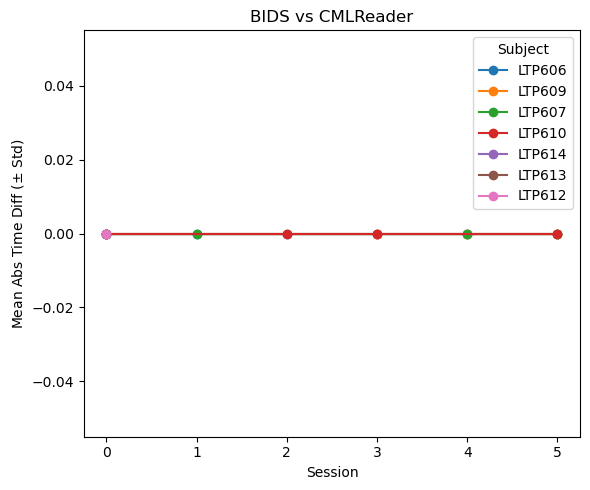

In [10]:
# plot mean and std difference
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

comparisons = df_time_all['comparison'].unique()
subjects = df_time_all['subject'].unique()

fig, axes = plt.subplots(1, len(comparisons), figsize=(6 * len(comparisons), 5), sharex=True)
if len(comparisons) == 1: axes = [axes]

for i, comp in enumerate(comparisons):
    ax = axes[i]
    comp_df = df_time_all[df_time_all['comparison'] == comp]
    
    for subj in subjects:
        subj_df = comp_df[comp_df['subject'] == subj].sort_values('session')
        if subj_df.empty: continue
        
        # Plot mean line
        line, = ax.plot(subj_df['session'], subj_df['mean_abs_time_diff'], marker='o', label=subj)
        
        # Add shaded Std region
        ax.fill_between(
            subj_df['session'], 
            subj_df['mean_abs_time_diff'] - subj_df['std_time_diff'],
            subj_df['mean_abs_time_diff'] + subj_df['std_time_diff'],
            color=line.get_color(), 
            alpha=0.15
        )
    
    ax.set_title(comp)
    ax.set_xlabel('Session')
    if i == 0: ax.set_ylabel('Mean Abs Time Diff ($\pm$ Std)')
    ax.legend(title='Subject')

plt.tight_layout()
plt.show()

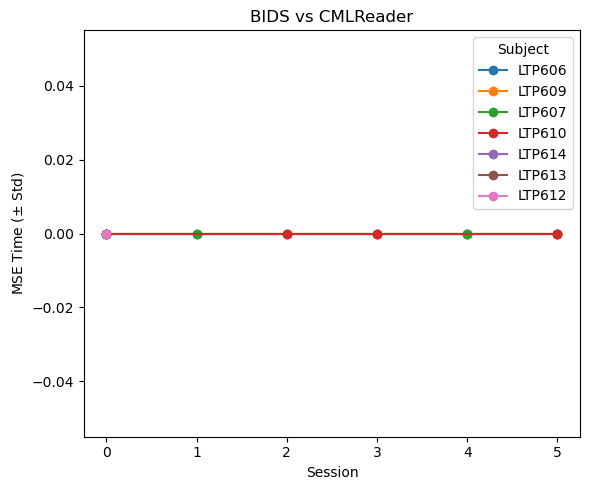

In [11]:
# plot mse
fig, axes = plt.subplots(1, len(comparisons), figsize=(6 * len(comparisons), 5), sharex=True)
if len(comparisons) == 1: axes = [axes]

for i, comp in enumerate(comparisons):
    ax = axes[i]
    comp_df = df_time_all[df_time_all['comparison'] == comp]
    
    for subj in subjects:
        subj_df = comp_df[comp_df['subject'] == subj].sort_values('session')
        if subj_df.empty: continue
        
        # Plot mean line
        line, = ax.plot(subj_df['session'], subj_df['mse_time'], marker='o', label=subj)
        
#         # Add shaded Std region
#         ax.fill_between(
#             subj_df['session'], 
#             subj_df['mean_abs_time_diff'] - subj_df['std_time_diff'],
#             subj_df['mean_abs_time_diff'] + subj_df['std_time_diff'],
#             color=line.get_color(), 
#             alpha=0.15
#         )
    
    ax.set_title(comp)
    ax.set_xlabel('Session')
    if i == 0: ax.set_ylabel('MSE Time ($\pm$ Std)')
    ax.legend(title='Subject')

plt.tight_layout()
plt.show()

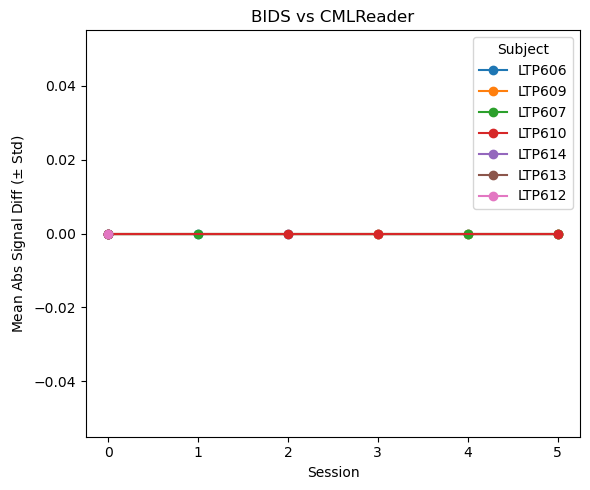

In [12]:
comparisons = df_raw_summary_all['comparison'].unique()
subjects = df_raw_summary_all['subject'].unique()

fig, axes = plt.subplots(1, len(comparisons), figsize=(6 * len(comparisons), 5), sharex=True)
if len(comparisons) == 1: axes = [axes]

for i, comp in enumerate(comparisons):
    ax = axes[i]
    comp_df = df_raw_summary_all[df_raw_summary_all['comparison'] == comp]
    
    for subj in subjects:
        subj_df = comp_df[comp_df['subject'] == subj].sort_values('session')
        if subj_df.empty: continue
        
        # Plot mean line
        line, = ax.plot(subj_df['session'], subj_df['mean_abs_diff'], marker='o', label=subj)
        
        # Add shaded Std region
        ax.fill_between(
            subj_df['session'], 
            subj_df['mean_abs_diff'] - subj_df['std_diff'],
            subj_df['mean_abs_diff'] + subj_df['std_diff'],
            color=line.get_color(), 
            alpha=0.15
        )
    
    ax.set_title(comp)
    ax.set_xlabel('Session')
    if i == 0: ax.set_ylabel('Mean Abs Signal Diff ($\pm$ Std)')
    ax.legend(title='Subject')

plt.tight_layout()
plt.show()

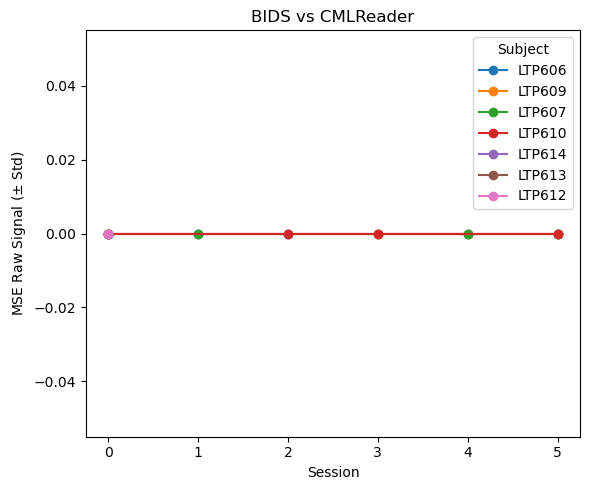

In [13]:
# plot mse
fig, axes = plt.subplots(1, len(comparisons), figsize=(6 * len(comparisons), 5), sharex=True)
if len(comparisons) == 1: axes = [axes]

for i, comp in enumerate(comparisons):
    ax = axes[i]
    comp_df = df_raw_summary_all[df_raw_summary_all['comparison'] == comp]
    
    for subj in subjects:
        subj_df = comp_df[comp_df['subject'] == subj].sort_values('session')
        if subj_df.empty: continue
        
        # Plot mean line
        line, = ax.plot(subj_df['session'], subj_df['mse'], marker='o', label=subj)
        
#         # Add shaded Std region
#         ax.fill_between(
#             subj_df['session'], 
#             subj_df['mean_abs_time_diff'] - subj_df['std_time_diff'],
#             subj_df['mean_abs_time_diff'] + subj_df['std_time_diff'],
#             color=line.get_color(), 
#             alpha=0.15
#         )
    
    ax.set_title(comp)
    ax.set_xlabel('Session')
    if i == 0: ax.set_ylabel('MSE Raw Signal ($\pm$ Std)')
    ax.legend(title='Subject')

plt.tight_layout()
plt.show()

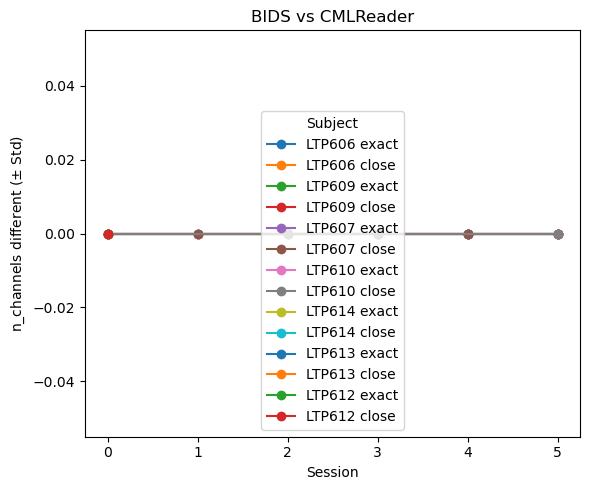

In [14]:
# plot n_channels diff
fig, axes = plt.subplots(1, len(comparisons), figsize=(6 * len(comparisons), 5), sharex=True)
if len(comparisons) == 1: axes = [axes]

for i, comp in enumerate(comparisons):
    ax = axes[i]
    comp_df = df_raw_summary_all[df_raw_summary_all['comparison'] == comp]
    
    for subj in subjects:
        subj_df = comp_df[comp_df['subject'] == subj].sort_values('session')
        if subj_df.empty: continue
        
        # Plot mean line
        line, = ax.plot(subj_df['session'], subj_df['n_exact_diff_channels'], marker='o', label=f"{subj} exact")
        line, = ax.plot(subj_df['session'], subj_df['n_close_diff_channels'], marker='o', label=f"{subj} close")
        
#         # Add shaded Std region
#         ax.fill_between(
#             subj_df['session'], 
#             subj_df['mean_abs_time_diff'] - subj_df['std_time_diff'],
#             subj_df['mean_abs_time_diff'] + subj_df['std_time_diff'],
#             color=line.get_color(), 
#             alpha=0.15
#         )
    
    ax.set_title(comp)
    ax.set_xlabel('Session')
    if i == 0: ax.set_ylabel('n_channels different ($\pm$ Std)')
    ax.legend(title='Subject')

plt.tight_layout()
plt.show()

In [15]:
df_raw_summary_all

,subject,experiment,session,comparison,source_a,source_b,n_common_channels,n_exact_diff_channels,n_close_diff_channels,mean_abs_diff,max_abs_diff,mean_signed_diff,std_diff,mse,n_samples_compared,exact_diff_channels,close_diff_channels
0,LTP606,ValueCourier,5,BIDS vs CMLReader,BIDS,CMLReader,137,0,0,0.0,0.0,0.0,0.0,0.0,5785600,[],[]
1,LTP606,ValueCourier,4,BIDS vs CMLReader,BIDS,CMLReader,137,0,0,0.0,0.0,0.0,0.0,0.0,9787392,[],[]
2,LTP606,ValueCourier,3,BIDS vs CMLReader,BIDS,CMLReader,137,0,0,0.0,0.0,0.0,0.0,0.0,9490432,[],[]
3,LTP609,ValueCourier,4,BIDS vs CMLReader,BIDS,CMLReader,137,0,0,0.0,0.0,0.0,0.0,0.0,9816064,[],[]
4,LTP607,ValueCourier,4,BIDS vs CMLReader,BIDS,CMLReader,137,0,0,0.0,0.0,0.0,0.0,0.0,10002432,[],[]
5,LTP607,ValueCourier,5,BIDS vs CMLReader,BIDS,CMLReader,137,0,0,0.0,0.0,0.0,0.0,0.0,9558016,[],[]
6,LTP606,ValueCourier,0,BIDS vs CMLReader,BIDS,CMLReader,137,0,0,0.0,0.0,0.0,0.0,0.0,10821632,[],[]
7,LTP607,ValueCourier,1,BIDS vs CMLReader,BIDS,CMLReader,137,0,0,0.0,0.0,0.0,0.0,0.0,10852352,[],[]
8,LTP606,ValueCourier,1,BIDS vs CMLReader,BIDS,CMLReader,137,0,0,0.0,0.0,0.0,0.0,0.0,11229184,[],[]
9,LTP610,ValueCourier,5,BIDS vs CMLReader,BIDS,CMLReader,137,0,0,0.0,0.0,0.0,0.0,0.0,11548672,[],[]


In [16]:
results["df_raw"]

NameError: name 'results' is not defined

In [17]:
results["df_time"]

,subject,experiment,session,comparison,time_len_a,time_len_b,time_compared_samples,n_exact_time_diff,n_close_time_diff,mean_abs_time_diff,max_abs_time_diff,mean_signed_time_diff,std_time_diff,mse_time
0,LTP606,ValueCourier,0,BIDS vs CMLReader,10821632,10821632,10821632,10821631,10821631,2.639358e+06,5.278716e+06,-2.639358e+06,1.523834e+06,9.288280e+12
1,LTP606,ValueCourier,0,BIDS vs PYEDFLIB,10821632,10821632,10821632,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,LTP606,ValueCourier,0,CMLReader vs PYEDFLIB,10821632,10821632,10821632,10821631,10821631,2.639358e+06,5.278716e+06,2.639358e+06,1.523834e+06,9.288280e+12


In [18]:
results["df_raw_summary"]

,subject,experiment,session,comparison,source_a,source_b,n_common_channels,n_exact_diff_channels,n_close_diff_channels,mean_abs_diff,max_abs_diff,mean_signed_diff,std_diff,mse,n_samples_compared,exact_diff_channels,close_diff_channels
0,LTP606,ValueCourier,0,BIDS vs CMLReader,BIDS,CMLReader,137,0,0,0.000000,0.0,0.000000,0.000000e+00,0.000000e+00,10821632,[],[]
1,LTP606,ValueCourier,0,BIDS vs PYEDFLIB,BIDS,PYEDFLIB,137,133,1,49749.956204,6815744.0,49749.956204,4.476645e-19,3.390830e+11,10821632,"[A1, A10, A11, A12, A13, A14, A15, A16, A17, A...",[Status]
2,LTP606,ValueCourier,0,CMLReader vs PYEDFLIB,CMLReader,PYEDFLIB,137,133,1,49749.956204,6815744.0,49749.956204,4.476645e-19,3.390830e+11,10821632,"[A1, A10, A11, A12, A13, A14, A15, A16, A17, A...",[Status]


In [19]:
results["eegs_std"]

[<xarray.DataArray 'eeg' (event: 1, channel: 137, time: 10821632)>
 array([[[ 6.90137787e-03,  6.89969038e-03,  6.90031537e-03, ...,
           6.13459804e-03,  6.13422304e-03,  6.13491054e-03],
         [ 1.91299803e-02,  1.91313553e-02,  1.91298240e-02, ...,
           1.37286778e-02,  1.37281778e-02,  1.37291778e-02],
         [ 1.89260588e-03,  1.89082463e-03,  1.88844963e-03, ...,
           2.63266701e-03,  2.63254201e-03,  2.63094826e-03],
         ...,
         [-2.59480724e-01, -2.59480661e-01, -2.59480880e-01, ...,
          -2.59476692e-01, -2.59476130e-01, -2.59476317e-01],
         [-2.59457130e-01, -2.59457786e-01, -2.59458161e-01, ...,
          -2.59454786e-01, -2.59454380e-01, -2.59453442e-01],
         [ 6.55360000e+04,  6.55360000e+04,  6.55360000e+04, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]]])
 Coordinates:
   * event       (event) int64 0
   * channel     (channel) <U6 'A1' 'A2' 'A3' 'A4' ... 'EXG7' 'EXG8' 'Status'
   * time        (time) 